In [52]:
"""
Setup: imports, Qdrant client, Postgres title lookup, embedding helper, and plotting utility.
Run this cell first before any of the vector space query cells.
"""
import asyncio
import os
import sys
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from qdrant_client import AsyncQdrantClient
from qdrant_client.models import SearchParams, QuantizationSearchParams
import psycopg

# Ensure the project root is on sys.path so "db.*" and "implementation.*" resolve
_project_root = str(Path.cwd().parent) if Path.cwd().name == "api" else str(Path.cwd())
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

load_dotenv()

# --- Qdrant connection ---
qdrant_client = AsyncQdrantClient(
    host=os.getenv("QDRANT_HOST", "localhost"),
    port=int(os.getenv("QDRANT_PORT", 6333)),
    timeout=10000,
)
COLLECTION = os.getenv("QDRANT_COLLECTION_ALIAS", "movies")

SEARCH_PARAMS = SearchParams(
    hnsw_ef=128,
    quantization=QuantizationSearchParams(rescore=False),
)

# --- Postgres connection (for title/year lookups) ---
_pg_conninfo = (
    f"host={os.getenv('POSTGRES_HOST')} "
    f"dbname={os.getenv('POSTGRES_DB')} "
    f"user={os.getenv('POSTGRES_USER')} "
    f"password={os.getenv('POSTGRES_PASSWORD')}"
)
_pg_conn = await psycopg.AsyncConnection.connect(_pg_conninfo)


async def fetch_movie_labels(movie_ids: list[int]) -> dict[int, dict]:
    """
    Fetch title, release year, and popularity percentile for a list of movie IDs from Postgres.
    Returns {movie_id: {"title": str, "year": int | None, "popularity_percentile": float | None}}.
    """
    if not movie_ids:
        return {}

    # Fetch title and release year from movie_card
    async with _pg_conn.cursor() as cur:
        await cur.execute(
            """
            SELECT mc.movie_id, mc.title, mc.release_ts, mv.percentile
            FROM public.movie_card mc
            LEFT JOIN public.mv_popularity_percentile mv ON mc.movie_id = mv.movie_id
            WHERE mc.movie_id = ANY(%s::bigint[])
            """,
            (movie_ids,),
        )
        rows = await cur.fetchall()

    labels = {}
    for movie_id, title, release_ts, percentile in rows:
        year = None
        if release_ts is not None:
            year = datetime.fromtimestamp(release_ts, tz=timezone.utc).year
        labels[movie_id] = {
            "title": title,
            "year": year,
            "popularity_percentile": float(percentile) if percentile is not None else None,
        }
    return labels


def sort_by_popularity(results: list[dict], descending: bool = True) -> list[dict]:
    """
    Sort a list of result dicts by popularity_percentile.
    Movies with no percentile are placed at the end.
    """
    return sorted(
        results,
        key=lambda r: (
            r.get("popularity_percentile") is not None,  # None values sort last
            r.get("popularity_percentile") or 0.0,
        ),
        reverse=descending,
    )


def _cosine_similarity(a: list[float], b: list[float]) -> float:
    """Compute cosine similarity between two vectors."""
    a_arr, b_arr = np.array(a), np.array(b)
    return float(np.dot(a_arr, b_arr) / (np.linalg.norm(a_arr) * np.linalg.norm(b_arr)))


async def _score_pinned_movies(
    pinned_ids: list[int],
    query_embedding: list[float],
    vector_name: str,
) -> dict[int, float]:
    """
    Retrieve stored vectors for pinned movie IDs and compute their
    cosine similarity against the query embedding.
    Returns {movie_id: cosine_similarity}.
    """
    if not pinned_ids:
        return {}
    points = await qdrant_client.retrieve(
        collection_name=COLLECTION,
        ids=pinned_ids,
        with_vectors=[vector_name],
    )
    scores = {}
    for pt in points:
        vec = pt.vector.get(vector_name) if isinstance(pt.vector, dict) else pt.vector
        if vec is not None:
            scores[pt.id] = _cosine_similarity(query_embedding, vec)
    return scores


# --- Embedding helper (OpenAI text-embedding-3-small) ---
from openai import AsyncOpenAI

_openai = AsyncOpenAI(api_key=os.getenv("OPENAI_API_KEY"), timeout=10.0)

async def embed(text: str) -> list[float]:
    """Embed a single query string and return the 1536-dim vector."""
    resp = await _openai.embeddings.create(
        model="text-embedding-3-small",
        input=[text],
    )
    return resp.data[0].embedding


async def query_vector_space(
    query: str,
    vector_name: str,
    limit: int = 20,
    pinned_ids: list[int] | None = None,
) -> tuple[list[dict], list[dict]]:
    """
    Query a single named vector space in Qdrant, then enrich results
    with title, year, and popularity percentile from Postgres.

    Args:
        query: The text query to embed and search with.
        vector_name: Which named vector space to search.
        limit: Number of nearest-neighbor results to return.
        pinned_ids: Optional list of tmdb_ids to score against the same
                    query and display alongside the ranked results.

    Returns:
        (ranked_results, pinned_results) — both are lists of dicts with
        keys: rank, movie_id, score, title, year, popularity_percentile.
        Pinned results have rank=None since they're positioned by score
        on the plot.
    """
    query_embedding = await embed(query)

    # Run nearest-neighbor search and pinned scoring in parallel
    nn_task = qdrant_client.query_points(
        collection_name=COLLECTION,
        query=query_embedding,
        using=vector_name,
        limit=limit,
        search_params=SEARCH_PARAMS,
        with_payload=False,
    )
    pinned_task = _score_pinned_movies(pinned_ids or [], query_embedding, vector_name)
    nn_results, pinned_scores = await asyncio.gather(nn_task, pinned_task)

    # Collect all movie IDs for a single Postgres lookup
    nn_movie_ids = [pt.id for pt in nn_results.points]
    all_movie_ids = list(set(nn_movie_ids + list(pinned_scores.keys())))
    labels = await fetch_movie_labels(all_movie_ids)

    def _make_entry(movie_id, score, rank=None):
        info = labels.get(movie_id, {})
        return {
            "rank": rank,
            "movie_id": movie_id,
            "score": score,
            "title": info.get("title", "Unknown"),
            "year": info.get("year"),
            "popularity_percentile": info.get("popularity_percentile"),
        }

    ranked = [
        _make_entry(pt.id, pt.score, rank=i + 1)
        for i, pt in enumerate(nn_results.points)
    ]

    # Build pinned list, excluding any that already appear in ranked results
    ranked_ids = {r["movie_id"] for r in ranked}
    pinned = [
        _make_entry(mid, score)
        for mid, score in sorted(pinned_scores.items(), key=lambda x: -x[1])
        if mid not in ranked_ids
    ]

    return ranked, pinned


def plot_results(
    ranked: list[dict],
    pinned: list[dict],
    vector_name: str,
    query: str,
):
    """
    Plot cosine similarity (y) vs rank (x) for nearest-neighbor results.
    Pinned movies are shown as labeled horizontal lines so you can see
    where they fall relative to the ranked results.
    """
    ranks = [r["rank"] for r in ranked]
    scores = [r["score"] for r in ranked]

    fig, ax = plt.subplots(figsize=(10, 4))

    # Plot the ranked curve
    ax.plot(ranks, scores, marker="o", linewidth=1.5, markersize=5, label="Nearest neighbors", zorder=2)

    # Draw horizontal lines for each pinned movie
    if pinned:
        colors = plt.cm.Set1(np.linspace(0, 1, max(len(pinned), 1)))
        for i, p in enumerate(pinned):
            year_str = str(p["year"]) if p["year"] else "N/A"
            label = f"{p['title']} ({year_str})"
            ax.axhline(y=p["score"], color=colors[i], linestyle="--", linewidth=1.5, alpha=0.8, label=label, zorder=1)

    ax.set_xlabel("Rank (nth closest)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"[{vector_name}]  \"{query}\"")
    ax.set_xticks(ranks)
    ax.grid(True, alpha=0.3)
    if pinned:
        ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    # Print ranked results
    for r in ranked:
        year_str = str(r["year"]) if r["year"] else "N/A"
        pct_str = f"  pop={r['popularity_percentile']:.1%}" if r["popularity_percentile"] is not None else ""
        print(f"  #{r['rank']:>3}  score={r['score']:.4f}{pct_str}  {r['title']} ({year_str})  [tmdb_id={r['movie_id']}]")

    # Print pinned results
    if pinned:
        print("\n  Pinned movies:")
        for p in pinned:
            year_str = str(p["year"]) if p["year"] else "N/A"
            pct_str = f"  pop={p['popularity_percentile']:.1%}" if p["popularity_percentile"] is not None else ""
            print(f"        score={p['score']:.4f}{pct_str}  {p['title']} ({year_str})  [tmdb_id={p['movie_id']}]")


print("Setup complete ✓")

Setup complete ✓


In [ ]:
# ── ANCHOR vector space ──
# Core thematic summary of the movie

QUERY = "a heist movie with a twist ending"
NUM_RESULTS = 20
PINNED_IDS = []  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "anchor", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "anchor", QUERY)

In [ ]:
# ── PLOT EVENTS vector space ──
# Plot details and character actions

QUERY = "a heist movie with a twist ending"
NUM_RESULTS = 20
PINNED_IDS = []  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "plot_events", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "plot_events", QUERY)

In [ ]:
# ── PLOT ANALYSIS vector space ──
# Themes, character arcs, and conceptual depth

QUERY = "a heist movie with a twist ending"
NUM_RESULTS = 20
PINNED_IDS = []  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "plot_analysis", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "plot_analysis", QUERY)

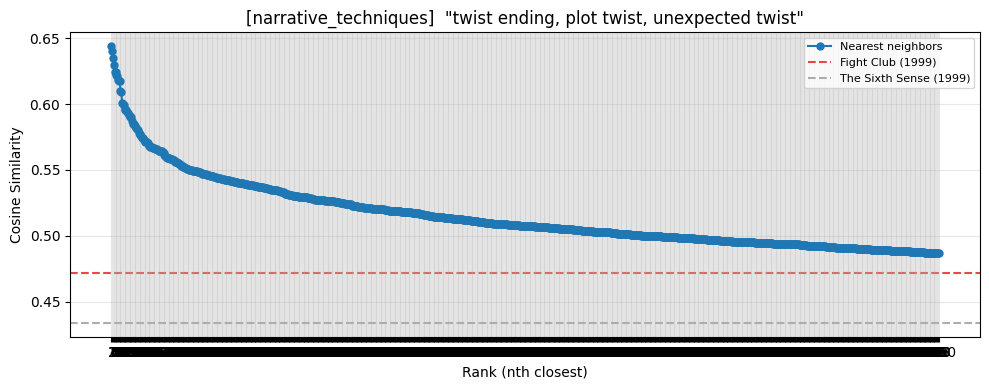

  #  1  score=0.6439  Strange Fruit (2004)  [tmdb_id=203808]
  #  2  score=0.6403  Sathru (2019)  [tmdb_id=471113]
  #  3  score=0.6348  House of Abraham (2025)  [tmdb_id=1477887]
  #  4  score=0.6294  Landfall (2017)  [tmdb_id=488059]
  #  5  score=0.6246  Knocking on Death's Door (1999)  [tmdb_id=104422]
  #  6  score=0.6241  Sleepwalking in Suburbia (2017)  [tmdb_id=473009]
  #  7  score=0.6223  Slightly Honorable (1939)  [tmdb_id=141510]
  #  8  score=0.6215  The Killer Is Calling (2025)  [tmdb_id=1420361]
  #  9  score=0.6180  White Sands (1992)  [tmdb_id=19380]
  # 10  score=0.6176  Four Bullets for Joe (1964)  [tmdb_id=158064]
  # 11  score=0.6176  Zid (2014)  [tmdb_id=310123]
  # 12  score=0.6098  The Wrong Son (2018)  [tmdb_id=530451]
  # 13  score=0.6090  Synapse (2021)  [tmdb_id=328950]
  # 14  score=0.6005  Way of the Wicked (2014)  [tmdb_id=255278]
  # 15  score=0.5997  Portal in the Pines (2025)  [tmdb_id=1466747]
  # 16  score=0.5989  Fatal Following (2021)  [tmdb_id=849

In [16]:
# ── NARRATIVE TECHNIQUES vector space ──
# Storytelling style, tone, and cinematic techniques

QUERY = "twist ending, plot twist, unexpected twist"
NUM_RESULTS = 1000
PINNED_IDS = [745,550]  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "narrative_techniques", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "narrative_techniques", QUERY)

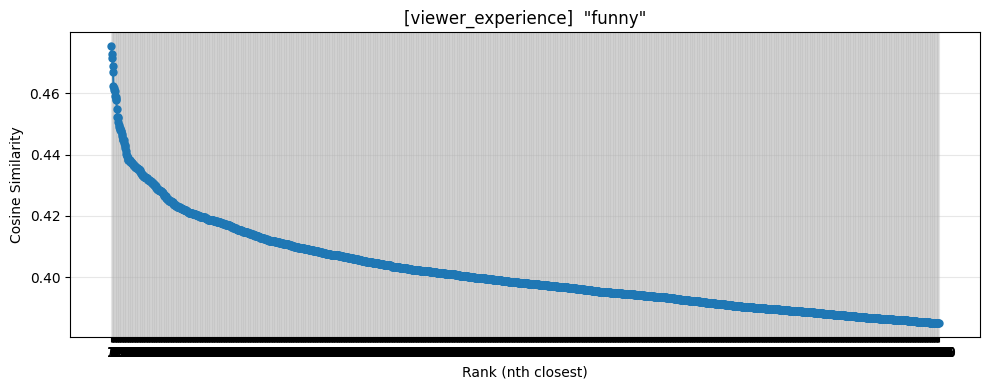

  #  1  score=0.4753  pop=49.7%  The Yes Men Are Revolting (2014)  [tmdb_id=284246]
  #  2  score=0.4727  pop=74.6%  Crazy Racer (2009)  [tmdb_id=33106]
  #  3  score=0.4716  pop=67.9%  Distracted (1970)  [tmdb_id=62675]
  #  4  score=0.4690  pop=45.5%  Drag-A-Long Droopy (1954)  [tmdb_id=84755]
  #  5  score=0.4671  pop=31.6%  Superior Duck (1996)  [tmdb_id=140695]
  #  6  score=0.4623  pop=3.5%  The Truth About Marriage (2020)  [tmdb_id=693640]
  #  7  score=0.4617  pop=81.4%  No Time for Nuts (2006)  [tmdb_id=46247]
  #  8  score=0.4609  pop=56.6%  Symphony in Slang (1951)  [tmdb_id=87197]
  #  9  score=0.4608  pop=76.9%  Deliha 2 (2018)  [tmdb_id=496748]
  # 10  score=0.4592  pop=45.6%  What a Mess (1982)  [tmdb_id=166721]
  # 11  score=0.4589  pop=44.7%  Perico Ripiao (2003)  [tmdb_id=25000]
  # 12  score=0.4581  pop=99.3%  Zoolander (2001)  [tmdb_id=9398]
  # 13  score=0.4578  pop=80.5%  Dance with the Jackals 2 (2012)  [tmdb_id=187976]
  # 14  score=0.4549  pop=42.4%  Hare Brush

In [46]:
# ── VIEWER EXPERIENCE vector space ──
# Emotional tone, pacing, and audience reaction

QUERY = "funny"
NUM_RESULTS = 2000
PINNED_IDS = []  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "viewer_experience", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "viewer_experience", QUERY)

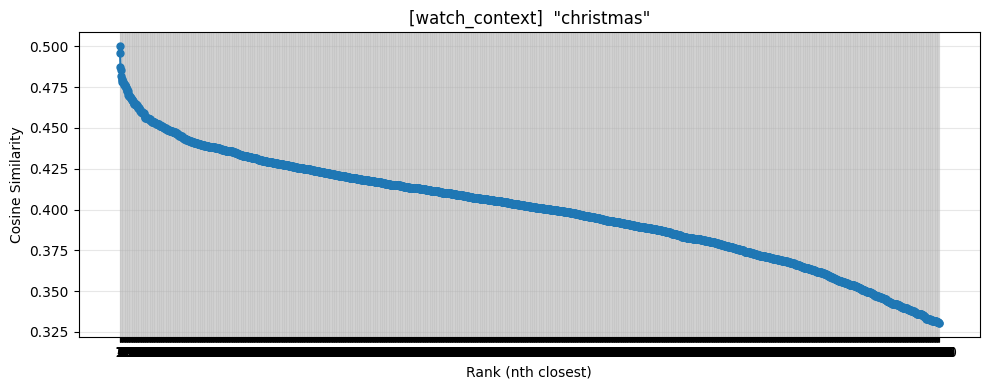

  #  1  score=0.5000  pop=38.1%  The Christmas Secret (2000)  [tmdb_id=81307]
  #  2  score=0.4957  pop=45.5%  Trans-Siberian Orchestra: The Ghosts of Christmas Eve (1999)  [tmdb_id=35966]
  #  3  score=0.4874  pop=7.9%  Stubby Pringle's Christmas (1978)  [tmdb_id=428385]
  #  4  score=0.4853  pop=9.1%  Christina Aguilera: Christmas in Paris (2025)  [tmdb_id=1563667]
  #  5  score=0.4816  pop=28.1%  The Spirit of Christmas (1953)  [tmdb_id=272459]
  #  6  score=0.4801  pop=10.8%  The Night Before Christmas (1968)  [tmdb_id=84074]
  #  7  score=0.4796  pop=58.6%  Yogi's First Christmas (1980)  [tmdb_id=45851]
  #  8  score=0.4780  pop=16.7%  Christmas Mountain: The Story Of A Cowboy Angel (1981)  [tmdb_id=403449]
  #  9  score=0.4779  pop=11.5%  O' Christmas Tree (1999)  [tmdb_id=50932]
  # 10  score=0.4779  pop=57.2%  Dolly Parton's Christmas of Many Colors: Circle of Love (2016)  [tmdb_id=426670]
  # 11  score=0.4770  pop=95.8%  A Charlie Brown Christmas (1965)  [tmdb_id=13187]
  # 12

In [45]:
# ── WATCH CONTEXT vector space ──
# When/how to watch: date night, background viewing, etc.

QUERY = "christmas"
NUM_RESULTS = 2000
PINNED_IDS = [] # [745,550]  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "watch_context", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "watch_context", QUERY)
# sorted_by_popularity = sort_by_popularity(results=ranked, descending=True)
# for result in sorted_by_popularity[:10]:
#     print(result)

In [ ]:
# ── PRODUCTION vector space ──
# Budget, filming locations, technical achievements, inspirations

QUERY = "a heist movie with a twist ending"
NUM_RESULTS = 20
PINNED_IDS = []  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "production", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "production", QUERY)

In [ ]:
# ── RECEPTION vector space ──
# Critical reception, awards, audience reaction

QUERY = "a heist movie with a twist ending"
NUM_RESULTS = 20
PINNED_IDS = []  # e.g. [550, 680, 155]

ranked, pinned = await query_vector_space(QUERY, "reception", limit=NUM_RESULTS, pinned_ids=PINNED_IDS)
plot_results(ranked, pinned, "reception", QUERY)

In [55]:
# ── CROSS-SEARCH OVERLAP ──
# Run multiple independent full searches and find movies that appear in ALL of them.
# Each search has its own query and independent flags for lexical and vector search.
# Lexical runs the full entity extraction pipeline; vector runs the full query
# expansion + multi-space vector search pipeline.

from db.postgres import pool
from db.lexical_search import lexical_search
from db.vector_search import run_vector_search
from implementation.classes.schemas import MetadataFilters

# Open the Postgres pool (required by lexical and vector search internals)
await pool.open()

# Each search: a query string with boolean flags for which channels to run.
# At least one of lexical/vector must be True per search.
SEARCHES = [
    {
        "query": "funny",
        "lexical": False,
        "vector": True,
        "top_n": 1000,  # how many candidates to consider from this search
    },
    {
        "query": "horror",
        "lexical": False,
        "vector": True,
        "top_n": 1000,
    },
]

TOP_N_DISPLAY = 100  # how many overlap results to print


async def run_single_search(
    query: str,
    use_lexical: bool,
    use_vector: bool,
    top_n: int,
) -> dict[int, float]:
    """
    Run one search using the specified channels (lexical and/or vector).
    Returns {movie_id: score} for the top_n candidates by score.

    When both channels are enabled, candidates from each are scored
    independently and we take the union — a movie's score is the sum
    of whichever channels returned it.
    """
    if not use_lexical and not use_vector:
        raise ValueError("At least one of lexical or vector must be True")

    tasks = {}
    if use_lexical:
        tasks["lexical"] = asyncio.ensure_future(lexical_search(query))
    if use_vector:
        tasks["vector"] = asyncio.ensure_future(
            run_vector_search(
                query=query,
                metadata_filters=MetadataFilters(),
                qdrant_client=qdrant_client,
            )
        )

    # Wait for all channels to complete
    await asyncio.gather(*tasks.values())

    # Merge scores: union of candidates, summing scores across channels
    merged: dict[int, float] = {}

    if "lexical" in tasks:
        lexical_result = tasks["lexical"].result()
        for c in lexical_result.candidates:
            merged[c.movie_id] = merged.get(c.movie_id, 0.0) + c.normalized_lexical_score

    if "vector" in tasks:
        vector_result = tasks["vector"].result()
        for movie_id, scores in vector_result.candidates.items():
            # Sum all non-zero vector scores for this candidate
            total = sum(
                getattr(scores, f.name)
                for f in scores.__dataclass_fields__.values()
            )
            merged[movie_id] = merged.get(movie_id, 0.0) + total

    # Keep only top_n by score
    sorted_candidates = sorted(merged.items(), key=lambda x: -x[1])[:top_n]
    return dict(sorted_candidates)


async def cross_search_overlap(
    searches: list[dict],
) -> list[dict]:
    """
    Run multiple independent searches in parallel and return movies
    that appear in ALL of them, sorted by total score.
    """
    tasks = [
        run_single_search(
            query=s["query"],
            use_lexical=s.get("lexical", False),
            use_vector=s.get("vector", True),
            top_n=s.get("top_n", 200),
        )
        for s in searches
    ]
    all_results = await asyncio.gather(*tasks)

    # Intersect movie IDs across all searches
    id_sets = [set(r.keys()) for r in all_results]
    common_ids = set.intersection(*id_sets) if id_sets else set()

    if not common_ids:
        print("No movies found across all searches.")
        return []

    # Fetch labels for overlapping movies
    labels = await fetch_movie_labels(list(common_ids))

    # Build output with per-search and total scores
    results = []
    for mid in common_ids:
        info = labels.get(mid, {})
        per_search_scores = [r[mid] for r in all_results]
        total_score = sum(per_search_scores)
        entry = {
            "movie_id": mid,
            "title": info.get("title", "Unknown"),
            "year": info.get("year"),
            "popularity_percentile": info.get("popularity_percentile"),
            "total_score": total_score,
        }
        for i, score in enumerate(per_search_scores):
            entry[f"search_{i+1}_score"] = score
        results.append(entry)

    results.sort(key=lambda r: r["total_score"], reverse=True)
    return results


results = await cross_search_overlap(SEARCHES)

# Print search descriptions
print(f"Found {len(results)} movies appearing in all {len(SEARCHES)} searches\n")
for i, s in enumerate(SEARCHES, 1):
    channels = []
    if s.get("lexical"):
        channels.append("lexical")
    if s.get("vector", True):
        channels.append("vector")
    print(f"  Search {i}: \"{s['query']}\" [{', '.join(channels)}, top {s.get('top_n', 200)}]")
print()

# Print top results
print(f"Top {TOP_N_DISPLAY} by total score:")
for i, r in enumerate(results[:TOP_N_DISPLAY], 1):
    year_str = str(r["year"]) if r["year"] else "N/A"
    pct_str = f"  pop={r['popularity_percentile']:.1%}" if r["popularity_percentile"] is not None else ""
    per_search = "  ".join(f"s{j+1}={r[f'search_{j+1}_score']:.4f}" for j in range(len(SEARCHES)))
    print(f"  #{i:>2}  total={r['total_score']:.4f}{pct_str}  {r['title']} ({year_str})  [{per_search}]")

Weight LLM returned not_relevant for production, skipping original-query search.
Weight LLM returned not_relevant for narrative_techniques, skipping original-query search.
Weight LLM returned not_relevant for watch_context, skipping original-query search.
Subquery LLM returned relevant_subquery_text as None for watch_context, skipping subquery search.
Subquery LLM returned relevant_subquery_text as None for production, skipping subquery search.
Weight LLM returned not_relevant for plot_events, skipping original-query search.
Subquery LLM returned relevant_subquery_text as None for plot_events, skipping subquery search.
Weight LLM returned not_relevant for plot_analysis, skipping original-query search.
Weight LLM returned not_relevant for reception, skipping original-query search.
Subquery LLM returned relevant_subquery_text as None for plot_events, skipping subquery search.
Subquery LLM returned relevant_subquery_text as None for narrative_techniques, skipping subquery search.
Subquery